<a href="https://colab.research.google.com/github/edgaryoungpilo-web/colab-files/blob/main/266659_Proyecto_Inicios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Actividad: Proyecto Analisis Descriptivo de los Datos - Etapa 2: EDA
Tema: Casos COVID-19 en Mexico

Materia: Programacion para analitica descriptiva y predicitva

Docente: Dr. Vicente Garcia Jimenez

Alumno: Edgar Soto Jimenez

Matricula: 266659

Periodo: Ene - May 2026

Fecha: 3/25/26

# Introduccion

Parte 1
*   Seleccion de conjunto de datos
*   Definicion del problema
*   Problema a estudiar
*   Justificacion
*   Analisis descriptivo

Parte 2

*   Descripcion del dataset
*   Revision de la calidad de datos
*   Procesamiento de datos
*   Analisis Univariado
*   Analisis bivariado
*   Analisis Multivariado
*   Visualizaciones para responder preguntas
*   Conclusiones




# Primera parte del proyecto

# Seleccion de conjunto de datos

*  Database: Base de datos de casos COVID-19 en Mexico

*   Portal Oficial: Gobierno de mexico - Datos abiertos

*   Fuente: Direccion general de epidemiologia

*   Portal Oficial:Gobierno de mexico - Datos abiertos

*  Enlace general: https://www.gob.mx/salud/documentos/datos-abiertos-152127


**Seleccion de conjunto de datos**

Tipo de datos:
*   Variables numericas (edad, fechas e indicadores binarios)
*   Variables binarias (intubado, neumonia, defuncion, hipertension, EPOC, etc)
*   Variables categoricas (Sexo, entidad federativa, tipo de paciente)


**Seleccion de conjunto de datos**

 Contexto: La investigacion fue realizada por el dpto. del sistma de salud de Mexico donde se registraron los casos oficiales y sospechosos de COVID-19 en Mexico, con el inicio, evolucion y descenlace del paciente.

# Definicion del problema

**Contexto del analisis**

La pandemia del COVID-19 registro un impacto significativo en Mexico. Analizar los datos oficiales nos puede permitir el comportamiento demografica de la pandemia y factores de mortalidad en la comunidad.

# Problema a estudiar

Identificar las caracteristicas asociadas a presentar mayor probabilidd de hopitalizacion y defuncion (enfermedades agudas o cronicas)

# Justificacion

Un analisis descriptivo nos permite entnder los grupos de riesgo y patrones epdemiologicos que apoyan a una correcta toma de desiciones

# Analisis descriptivo

 Formulacion de preguntas



1.   ¿Que proporcion de pacientes fue hospitalizada?

2.   ¿Que es la distribucion de edad en los pacientes?

3.   ¿Que porcentaje de los casos corresponde a hombres y mujeres?

4. ¿Cual es la tasa de defuncion registrada?

5. ¿Existe relacion entre edad y la probabilidad de defuncion?

# Segunda parte del proyecto

# Parte 1. Librerias

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

# Parte 2. Carga de datos

In [5]:
from google.colab import drive
drive.mount('/content/drive')

ruta_data = '/content/drive/MyDrive/Colab Notebooks/COVID19MEXICO.csv'
ruta_catalogo = '/content/drive/MyDrive/Colab Notebooks/240708 Catalogos.xlsx'

df = pd.read_csv(ruta_data, low_memory=False)
catalogos = pd.read_excel(ruta_catalogo, sheet_name=None)

# Normalizar columnas
df.columns = df.columns.str.upper().str.strip()

df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,FECHA_ACTUALIZACION,ID_REGISTRO,ORIGEN,SECTOR,ENTIDAD_UM,SEXO,ENTIDAD_NAC,ENTIDAD_RES,MUNICIPIO_RES,TIPO_PACIENTE,...,RESULTADO_PCR,RESULTADO_PCR_COINFECCION,TOMA_MUESTRA_ANTIGENO,RESULTADO_ANTIGENO,CLASIFICACION_FINAL_COVID,CLASIFICACION_FINAL_FLU,MIGRANTE,PAIS_NACIONALIDAD,PAIS_ORIGEN,UCI
0,2026-02-17,028856,1,12,14,2,15,9,14,1,...,999,999,2,97,6,6,99,México,97,97
1,2026-02-17,167f1a,1,12,1,2,1,1,3,1,...,997,997,2,97,6,6,99,México,97,97
2,2026-02-17,df61d0,1,15,9,1,9,9,11,1,...,997,997,2,97,6,6,99,México,97,97
3,2026-02-17,60bdae,1,15,29,1,29,29,50,1,...,997,997,2,97,6,6,99,México,97,97
4,2026-02-17,109fd5,1,12,1,1,1,1,1,2,...,5,5,2,97,7,7,99,México,97,2


# Parte 3. Descripcion del dataset

In [ ]:
print("Dimensiones:", df.shape)
df.info()
df.describe()

Dimensiones: (187258, 42)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187258 entries, 0 to 187257
Data columns (total 42 columns):
 #   Column                     Non-Null Count   Dtype 
---  ------                     --------------   ----- 
 0   FECHA_ACTUALIZACION        187258 non-null  object
 1   ID_REGISTRO                187258 non-null  object
 2   ORIGEN                     187258 non-null  int64 
 3   SECTOR                     187258 non-null  int64 
 4   ENTIDAD_UM                 187258 non-null  int64 
 5   SEXO                       187258 non-null  int64 
 6   ENTIDAD_NAC                187258 non-null  int64 
 7   ENTIDAD_RES                187258 non-null  int64 
 8   MUNICIPIO_RES              187258 non-null  int64 
 9   TIPO_PACIENTE              187258 non-null  int64 
 10  FECHA_INGRESO              187258 non-null  object
 11  FECHA_SINTOMAS             187258 non-null  object
 12  FECHA_DEF                  187258 non-null  object
 13  INTUBADO          

,ORIGEN,SECTOR,ENTIDAD_UM,SEXO,ENTIDAD_NAC,ENTIDAD_RES,MUNICIPIO_RES,TIPO_PACIENTE,INTUBADO,NEUMONIA,...,OTRO_CASO,TOMA_MUESTRA_LAB,RESULTADO_PCR,RESULTADO_PCR_COINFECCION,TOMA_MUESTRA_ANTIGENO,RESULTADO_ANTIGENO,CLASIFICACION_FINAL_COVID,CLASIFICACION_FINAL_FLU,MIGRANTE,UCI
count,187258.0,187258.000000,187258.000000,187258.000000,187258.000000,187258.000000,187258.000000,187258.000000,187258.000000,187258.000000,...,187258.000000,187258.000000,187258.000000,187258.000000,187258.0,187258.0,187258.000000,187258.000000,187258.000000,187258.000000
mean,1.0,8.382697,16.069097,1.445375,16.783491,16.319121,46.532885,1.468883,52.455308,1.755834,...,4.456509,1.352466,374.158562,543.175667,2.0,97.0,6.430785,6.208226,98.644763,52.462421
std,0.0,4.359584,8.490028,0.497008,9.948298,8.398544,59.984905,0.499032,47.429843,0.429593,...,15.793771,0.477739,477.657609,494.055653,0.0,0.0,0.873469,1.162019,5.867072,47.422200
min,1.0,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,2.0,97.0,3.000000,3.000000,1.000000,1.000000
25%,1.0,4.000000,9.000000,1.000000,9.000000,9.000000,8.000000,1.000000,2.000000,2.000000,...,2.000000,1.000000,5.000000,5.000000,2.0,97.0,6.000000,6.000000,99.000000,2.000000
50%,1.0,6.000000,15.000000,1.000000,15.000000,15.000000,25.000000,1.000000,97.000000,2.000000,...,2.000000,1.000000,5.000000,997.000000,2.0,97.0,7.000000,7.000000,99.000000,97.000000
75%,1.0,12.000000,21.000000,2.000000,21.000000,21.000000,60.000000,2.000000,97.000000,2.000000,...,2.000000,2.000000,997.000000,997.000000,2.0,97.0,7.000000,7.000000,99.000000,97.000000
max,1.0,15.000000,32.000000,2.000000,99.000000,32.000000,999.000000,2.000000,99.000000,2.000000,...,99.000000,2.000000,999.000000,999.000000,2.0,97.0,7.000000,7.000000,99.000000,99.000000




*  Dataset grande de pacientes COVID en Mexico
*  Variables mayormente categoricas codificadas



# Parte 4. Crear diccionarios

In [ ]:
diccionarios = {}

for nombre, tabla in catalogos.items():
    try:
        tabla = tabla.dropna()
        col_codigo = tabla.columns[0]
        col_desc = tabla.columns[1]

        dic = dict(zip(tabla[col_codigo], tabla[col_desc]))
        diccionarios[nombre.upper()] = dic

    except:
        print(f"Error en hoja: {nombre}")

# Parte 5. Limpieza inteligente

In [ ]:
# Valores especiales del dataset
valores_invalidos = [97, 98, 99, 999]

for col in df.columns:
    if df[col].dtype != 'object':
        df[col] = df[col].replace(valores_invalidos, np.nan)

# Parte 6. Aplicar catalogos

In [ ]:
for col in df.columns:
    if col in diccionarios:
        df[col] = df[col].map(diccionarios[col])

# Parte 7. Convertir categorias

In [ ]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype('category')

# Pate 8. Limpieza de edad

In [ ]:
# Filtrar edades irreales
df = df[(df['EDAD'] >= 0) & (df['EDAD'] <= 120)]

# Parte 9. Valores faltantes

In [ ]:
# Imputación simple
df.fillna(df.median(numeric_only=True), inplace=True)

In [ ]:
df.isnull().sum()

,0
FECHA_ACTUALIZACION,0
ID_REGISTRO,0
ORIGEN,0
SECTOR,0
ENTIDAD_UM,0
SEXO,0
ENTIDAD_NAC,781
ENTIDAD_RES,0
MUNICIPIO_RES,1499
TIPO_PACIENTE,0


# Parte 10. Outliers

In [ ]:
Q1 = df['EDAD'].quantile(0.25)
Q3 = df['EDAD'].quantile(0.75)
IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

outliers = df[(df['EDAD'] < lim_inf) | (df['EDAD'] > lim_sup)]

print("Outliers en edad:", outliers.shape[0])

Outliers en edad: 0


# Parte 11. Visualizaciones

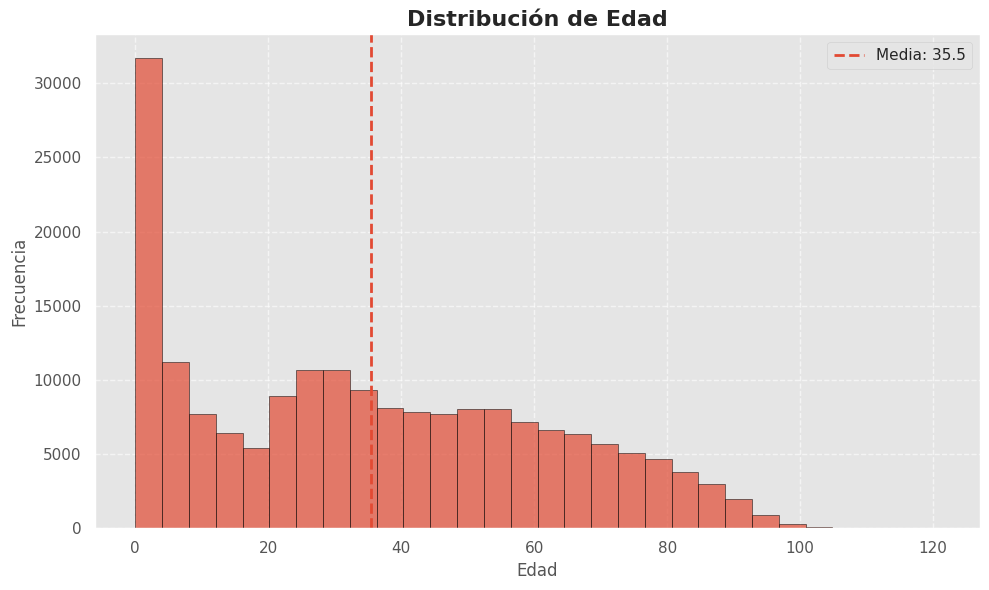

In [10]:
# Histograma

import matplotlib.pyplot as plt

# Configuración general del estilo
plt.style.use('ggplot')

# Crear figura
plt.figure(figsize=(10,6))

# Histograma
plt.hist(df['EDAD'], bins=30, edgecolor='black', alpha=0.7)

# Títulos y etiquetas
plt.title("Distribución de Edad", fontsize=16, fontweight='bold')
plt.xlabel("Edad", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)

# Líneas de referencia (media)
media = df['EDAD'].mean()
plt.axvline(media, linestyle='dashed', linewidth=2, label=f'Media: {media:.1f}')

# Leyenda
plt.legend()

# Mejorar layout
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Mostrar
plt.show()



"Interpretación de la gráfica: Distribución de Edad

Se cuenta con una visualización de un histograma que muestra cómo se distribuyen los valores de una variable numérica (en este caso, la edad).

El eje X (horizontal) representa las edades.
El eje Y (vertical) muestra la frecuencia, es decir, cuántas personas hay en cada rango de edad. Agrupando un rango de edades (definido por bins=30):

Simétrica (normal): edades distribuidas de manera equilibrada.
Sesgada a la derecha: más personas jóvenes y pocas mayores.
Sesgada a la izquierda: más personas mayores y pocas jóvenes.
Multimodal: varios picos → puede haber distintos grupos (ej. jóvenes y adultos).

La línea vertical punteada representa la media (promedio) de las edades:

“La mayoría de la población se concentra entre X y Y años”
“La distribución presenta un sesgo hacia edades jóvenes”
“Existe poca variabilidad en la edad”
“Se detectan posibles valores atípicos”"


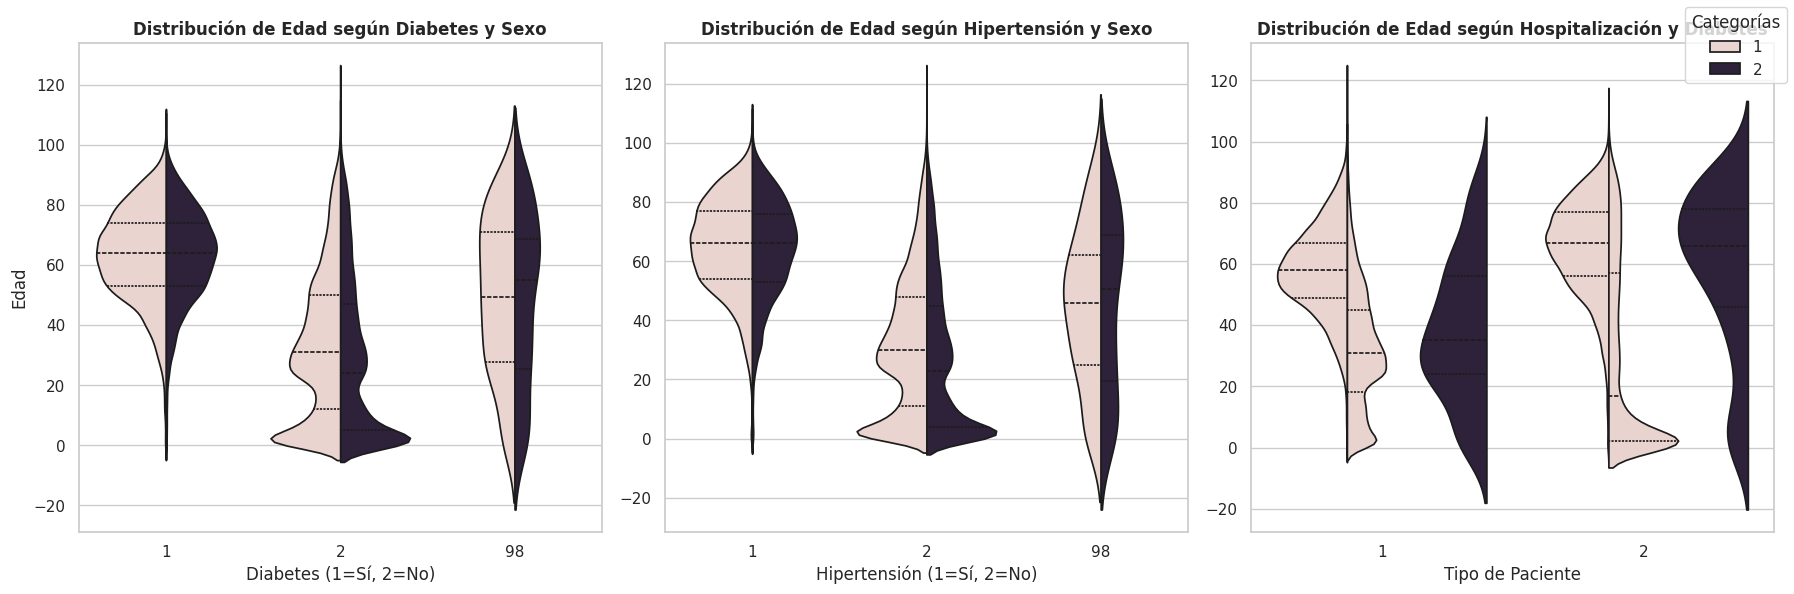

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Estilo profesional
sns.set(style="whitegrid", palette="muted")

# Crear figura con subplots
fig, axes = plt.subplots(1, 3, figsize=(18,6))

# --- 1. Diabetes vs Edad vs Sexo ---
sns.violinplot(
    ax=axes[0],
    x='DIABETES',
    y='EDAD',
    hue='SEXO',
    data=df,
    split=True,          # divide el violín por sexo
    inner='quartile'     # muestra cuartiles dentro
)

axes[0].set_title("Distribución de Edad según Diabetes y Sexo", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Diabetes (1=Sí, 2=No)")
axes[0].set_ylabel("Edad")

# --- 2. Hipertensión vs Edad vs Sexo ---
sns.violinplot(
    ax=axes[1],
    x='HIPERTENSION',
    y='EDAD',
    hue='SEXO',
    data=df,
    split=True,
    inner='quartile'
)

axes[1].set_title("Distribución de Edad según Hipertensión y Sexo", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Hipertensión (1=Sí, 2=No)")
axes[1].set_ylabel("")

# --- 3. Tipo de paciente vs Edad vs Diabetes ---
sns.violinplot(
    ax=axes[2],
    x='TIPO_PACIENTE',
    y='EDAD',
    hue='DIABETES',
    data=df,
    split=True,
    inner='quartile'
)

axes[2].set_title("Distribución de Edad según Hospitalización y Diabetes", fontsize=12, fontweight='bold')
axes[2].set_xlabel("Tipo de Paciente")
axes[2].set_ylabel("")

# Ajustar leyenda (una sola global)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Categorías", loc='upper right')

# Quitar leyendas repetidas
for ax in axes:
    ax.get_legend().remove()

# Ajustar layout
plt.tight_layout()

# Mostrar
plt.show()

df['DIABETES'] = df['DIABETES'].map({1: 'Sí', 2: 'No'})
df['HIPERTENSION'] = df['HIPERTENSION'].map({1: 'Sí', 2: 'No'})
df['SEXO'] = df['SEXO'].map({1: 'Mujer', 2: 'Hombre'})

**Analisis de Boxplot**

1. Edad según Diabetes y Sexo.

Se observa que la distribución de edad en pacientes con diabetes tiende a concentrarse en rangos de mayor edad en comparación con los pacientes sin diabetes.
La forma del violín sugiere una mayor densidad en edades adultas y adultas mayores, lo que indica que la diabetes es más frecuente en estos grupos.
En cuanto al sexo:
No se aprecia una diferencia extremadamente marcada en la distribución, pero pueden existir ligeras variaciones en dispersión entre hombres y mujeres.
La presencia de colas más largas indica que existen casos en edades más jóvenes, aunque son menos frecuentes.

Conclusión:
La diabetes está asociada principalmente a poblaciones de mayor edad, con una distribución relativamente similar entre sexos.

2. Edad según Hipertensión y Sexo.

La hipertensión muestra un patrón aún más claro hacia edades avanzadas, con una concentración notable en adultos mayores.
La distribución es más “ancha” en edades altas, lo que indica mayor densidad de casos en ese rango.
En comparación con los no hipertensos:
Estos presentan una distribución más dispersa y con mayor presencia en edades medias.
Por sexo:
Se pueden observar pequeñas diferencias en la forma del violín, lo que sugiere posibles variaciones en la distribución por género, aunque no necesariamente significativas.

Conclusión:
La hipertensión está fuertemente relacionada con la edad, siendo mucho más común en personas mayores.

3. Edad según Tipo de Paciente y Diabetes.

Los pacientes hospitalizados tienden a concentrarse en edades más altas, especialmente cuando también presentan diabetes.
En pacientes ambulatorios:
Se observa una distribución más amplia, incluyendo edades más jóvenes.
La combinación hospitalización + diabetes muestra:
Mayor densidad en edades avanzadas
Menor presencia de pacientes jóvenes

Conclusión:
La hospitalización está asociada a pacientes de mayor edad y con condiciones como diabetes, lo que sugiere mayor severidad en estos grupos.

**Conclusión General del Análisis.**

La edad es un factor determinante en la presencia de enfermedades como diabetes e hipertensión.
Ambas condiciones presentan una mayor concentración en adultos mayores, lo que coincide con patrones epidemiológicos conocidos.
La hospitalización también está relacionada con mayor edad y comorbilidades, indicando mayor riesgo en estos grupos.
Las diferencias por sexo existen, pero no parecen ser el factor principal en comparación con la edad.

FECHA_INGRESO     datetime64[ns]
FECHA_SINTOMAS    datetime64[ns]
dtype: object


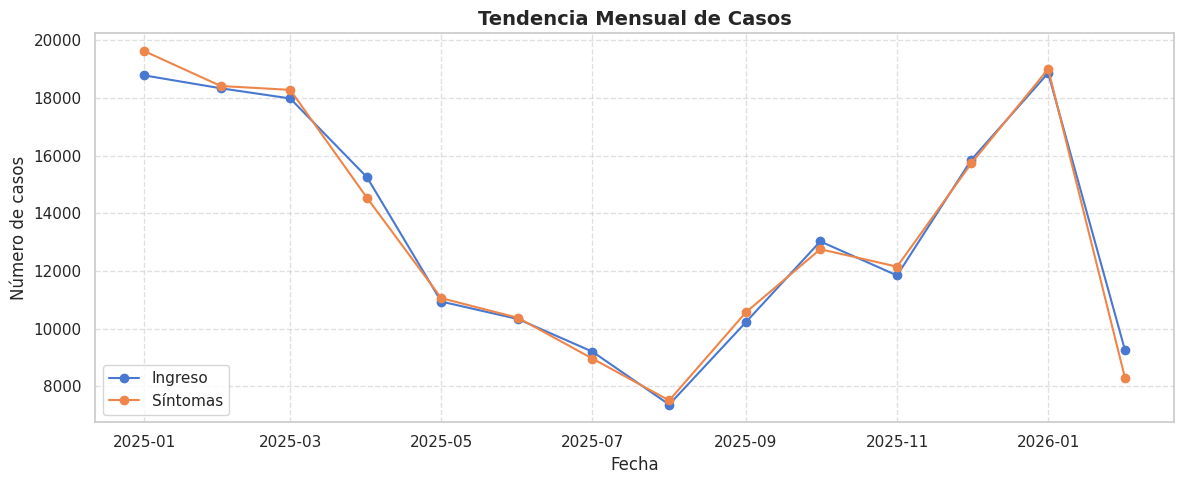

In [15]:
# Variables categoricas
import pandas as pd
import matplotlib.pyplot as plt

# Convertir a formato datetime
df['FECHA_INGRESO'] = pd.to_datetime(df['FECHA_INGRESO'], errors='coerce')
df['FECHA_SINTOMAS'] = pd.to_datetime(df['FECHA_SINTOMAS'], errors='coerce')

# Verificar (opcional pero recomendado)
print(df[['FECHA_INGRESO', 'FECHA_SINTOMAS']].dtypes)

# Agrupar por mes
ingreso_mensual = df['FECHA_INGRESO'].dt.to_period('M').value_counts().sort_index()
sintomas_mensual = df['FECHA_SINTOMAS'].dt.to_period('M').value_counts().sort_index()

# Convertir índice a timestamp
ingreso_mensual.index = ingreso_mensual.index.to_timestamp()
sintomas_mensual.index = sintomas_mensual.index.to_timestamp()

# Graficar
plt.figure(figsize=(12,5))

plt.plot(ingreso_mensual, marker='o', label='Ingreso')
plt.plot(sintomas_mensual, marker='o', label='Síntomas')

plt.title("Tendencia Mensual de Casos", fontsize=14, fontweight='bold')
plt.xlabel("Fecha")
plt.ylabel("Número de casos")
plt.legend()

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**Analisis de la grafica**.

La mayoría de los pacientes presenta un tiempo corto entre síntomas e ingreso, lo que indica respuesta relativamente rápida.
Una distribución con cola larga sugiere que algunos pacientes tardan más en acudir al sistema de salud.
Valores altos pueden indicar:
retraso en atención médica
baja percepción de riesgo
saturación del sistema

**Conclusión**:

El tiempo entre síntomas e ingreso es un indicador crítico de acceso y respuesta del sistema de salud

# Parte 12 Analisis bivariado

/tmp/ipykernel_3404/2080044810.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


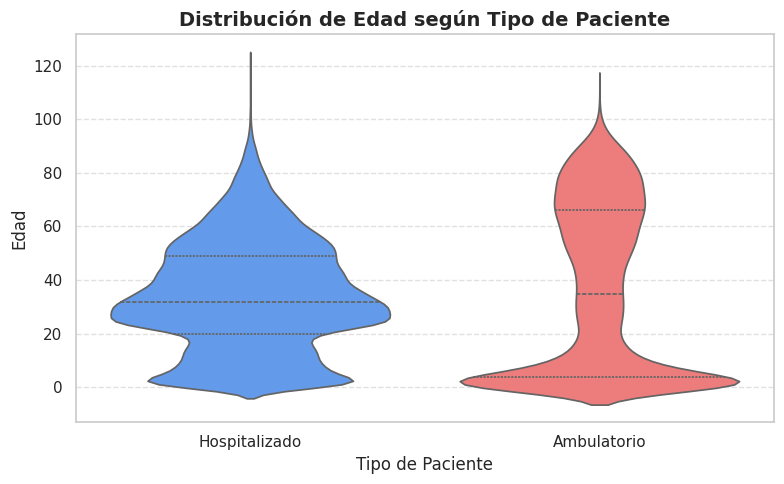

In [35]:
# Correlacion entre personas con diabetes en relacion a la edad de los pacientes
# Tipo 1: Con diabetes
# Tipo 2: Sin diabetes

import seaborn as sns
import matplotlib.pyplot as plt

# Verificar columna
if 'TIPO_PACIENTE' in df.columns:

    # Copia para visualización
    df_vis = df.copy()

    # Mapear valores (más profesional)
    df_vis['TIPO_PACIENTE'] = df_vis['TIPO_PACIENTE'].map({
        1: 'Hospitalizado',
        2: 'Ambulatorio'
    })

    # Eliminar nulos
    df_vis = df_vis.dropna(subset=['TIPO_PACIENTE', 'EDAD'])

    # Estilo
    sns.set(style="whitegrid")

    # Figura
    plt.figure(figsize=(8,5))

    # Violin plot
    sns.violinplot(
        x='TIPO_PACIENTE',
        y='EDAD',
        data=df_vis,
        inner='quartile',     # muestra cuartiles
        palette=['#4D96FF', '#FF6B6B']
    )

    # Títulos
    plt.title("Distribución de Edad según Tipo de Paciente", fontsize=14, fontweight='bold')
    plt.xlabel("Tipo de Paciente")
    plt.ylabel("Edad")

    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# Parte 13. Correlacion

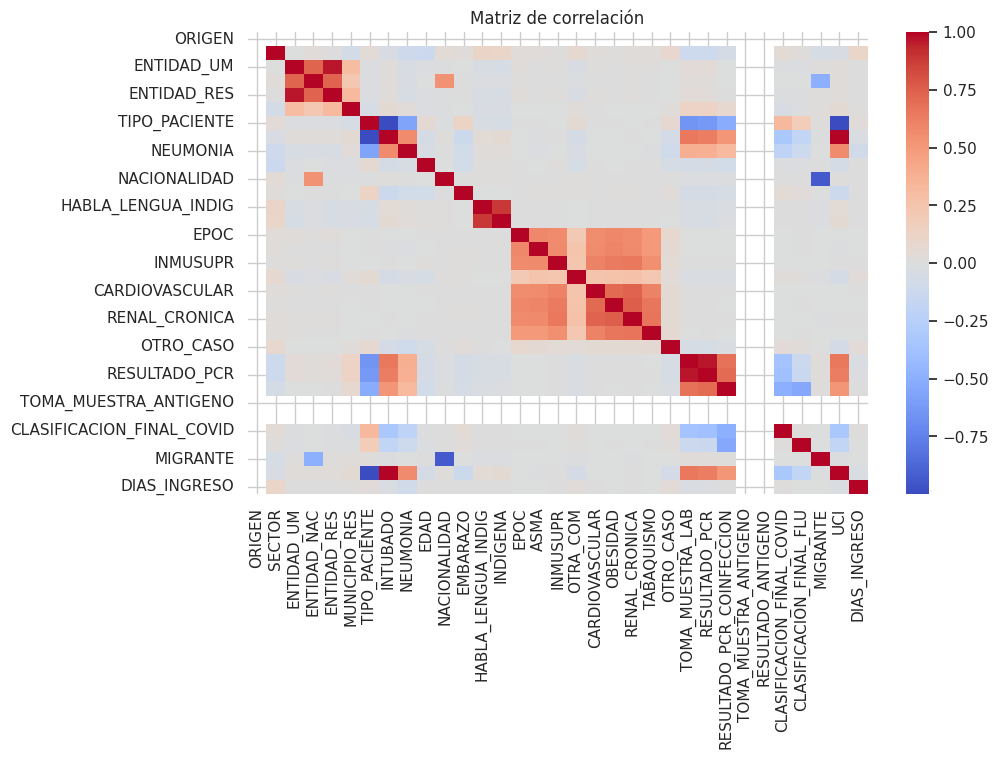

In [22]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, cmap='coolwarm')
plt.title("Matriz de correlación")
plt.show()


# Parte 14. Multivariado

In [ ]:
sns.pairplot(df.select_dtypes(include=np.number).sample(1000))
plt.show()

KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x7c31a384ccc0> (for post_execute):


KeyboardInterrupt: 

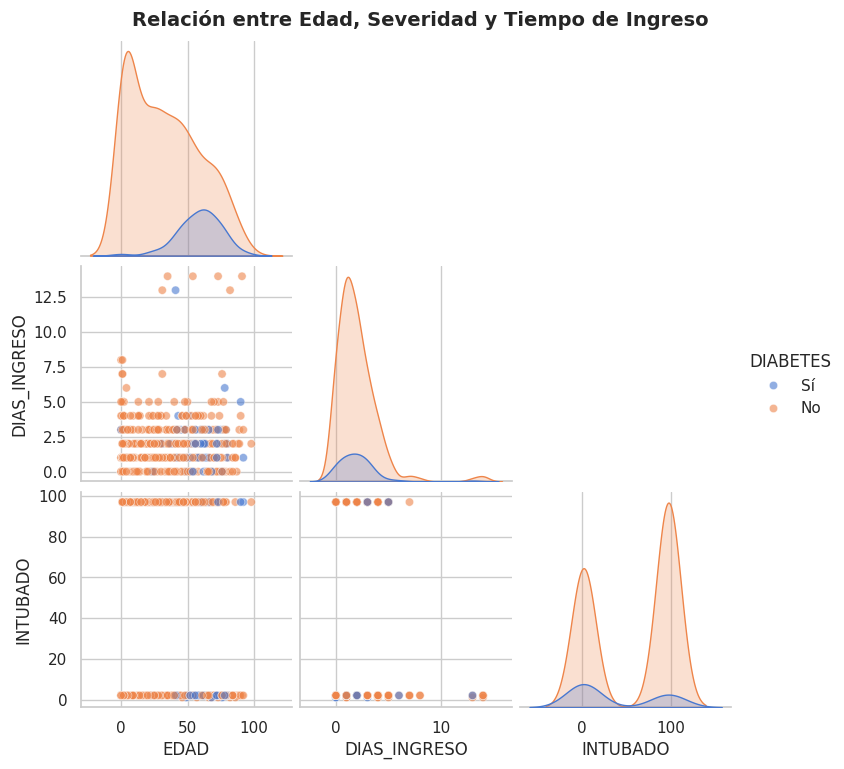

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Selección inteligente de variables
cols = ['EDAD', 'DIAS_INGRESO', 'INTUBADO']

# Dataset reducido
df_sample = df[cols + ['DIABETES']].dropna().sample(500, random_state=42)

# Pairplot profesional
sns.pairplot(
    df_sample,
    hue='DIABETES',
    diag_kind='kde',
    corner=True,
    plot_kws={'alpha':0.6}
)

plt.suptitle("Relación entre Edad, Severidad y Tiempo de Ingreso",
             y=1.02, fontsize=14, fontweight='bold')

plt.show()


Interpretacion

La edad se mantiene como el principal factor asociado a la severidad.
Los pacientes con diabetes muestran patrones diferenciados en la distribución.
Los casos más graves (intubados) tienden a concentrarse en ciertos rangos de edad.
El tiempo de ingreso puede variar dependiendo de condiciones

# Parte 15. Seccion de respuesta a preguntas

Pregunta 1: Que proporcion de pacientes fueron hospitalizados?

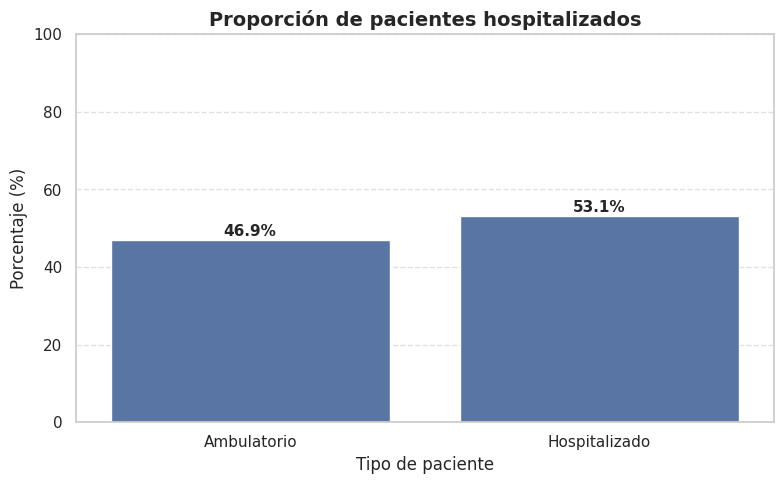

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convertir valores a etiquetas (opcional pero recomendado)
df_vis = df.copy()
df_vis['TIPO_PACIENTE'] = df_vis['TIPO_PACIENTE'].map({1: 'Hospitalizado', 2: 'Ambulatorio'})

# Calcular proporciones
hospitalizados = df_vis['TIPO_PACIENTE'].value_counts(normalize=True) * 100

# Ordenar
hospitalizados = hospitalizados.sort_values()

# Estilo
sns.set(style="whitegrid")

# Crear figura
plt.figure(figsize=(8,5))

# Gráfica
ax = sns.barplot(
    x=hospitalizados.index,
    y=hospitalizados.values
)

# Etiquetas encima de barras
for i, v in enumerate(hospitalizados.values):
    ax.text(i, v + 1, f"{v:.1f}%", ha='center', fontsize=11, fontweight='bold')

# Títulos y etiquetas
plt.title("Proporción de pacientes hospitalizados", fontsize=14, fontweight='bold')
plt.xlabel("Tipo de paciente")
plt.ylabel("Porcentaje (%)")

# Mejorar visual
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Pregunta 2. Cual es la distribucion de edad?

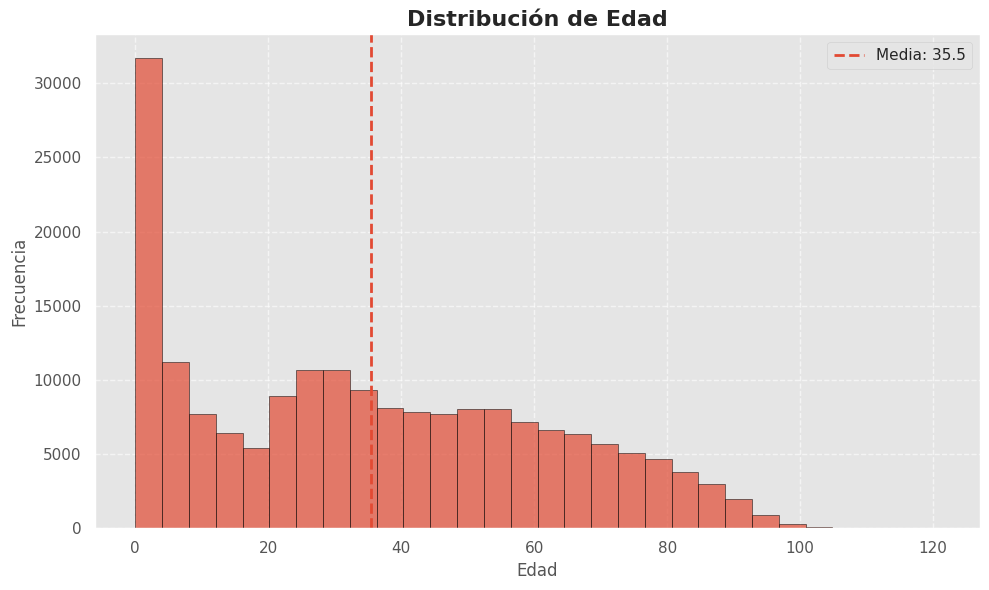

In [25]:
# Histograma

import matplotlib.pyplot as plt

# Configuración general del estilo
plt.style.use('ggplot')

# Crear figura
plt.figure(figsize=(10,6))

# Histograma
plt.hist(df['EDAD'], bins=30, edgecolor='black', alpha=0.7)

# Títulos y etiquetas
plt.title("Distribución de Edad", fontsize=16, fontweight='bold')
plt.xlabel("Edad", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)

# Líneas de referencia (media)
media = df['EDAD'].mean()
plt.axvline(media, linestyle='dashed', linewidth=2, label=f'Media: {media:.1f}')

# Leyenda
plt.legend()

# Mejorar layout
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Mostrar
plt.show()

Pregunta 3. Que porcentaje corresponde a Mujeres y hombres?

SEXO
Mujer     55.462517
Hombre    44.537483
Name: proportion, dtype: float64


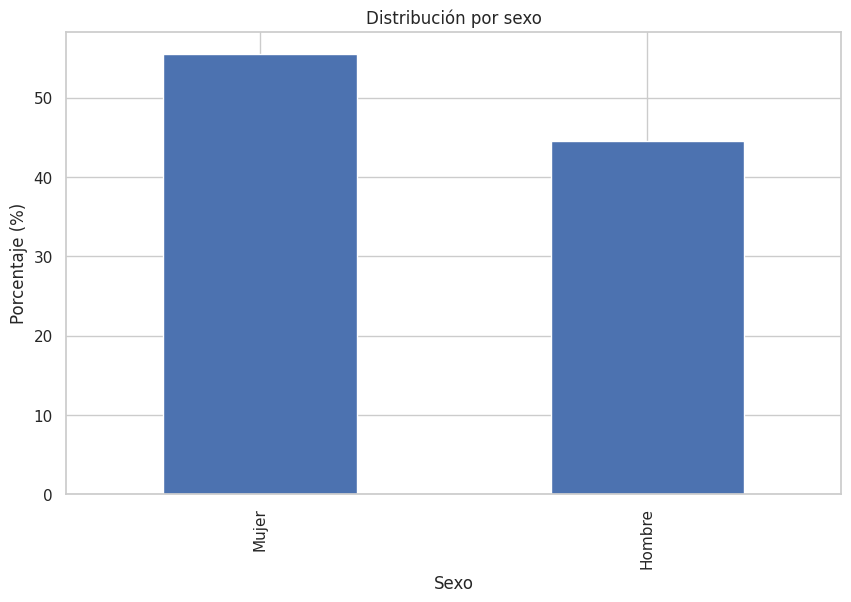

In [32]:
import matplotlib.pyplot as plt

# Calcular porcentajes
sexo_pct = df['SEXO'].value_counts(normalize=True) * 100

# Imprimir resultados
print(sexo_pct)

# Gráfica
sexo_pct.plot(kind='bar')

plt.title("Distribución por sexo")
plt.xlabel("Sexo")
plt.ylabel("Porcentaje (%)")

plt.show()

Pregunta 4.  Cual es la tasa de defuncion?

Tasa de defunción: 100.00%


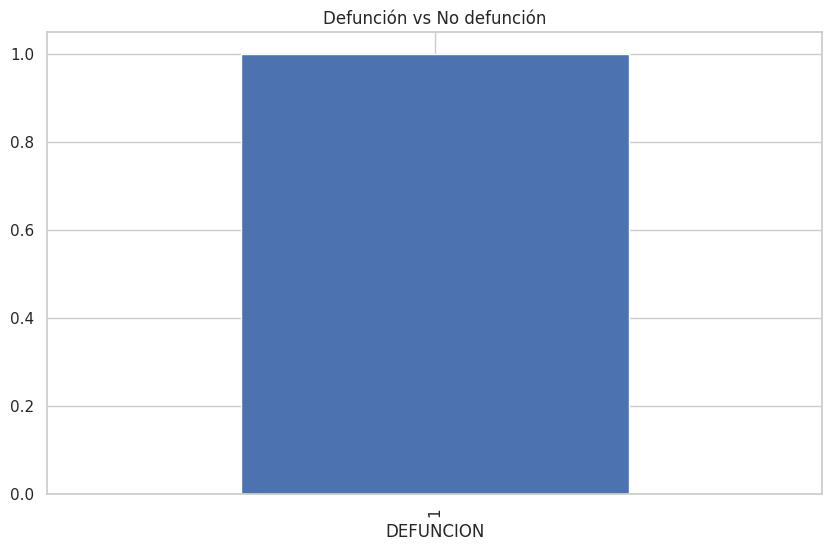

In [ ]:
# Crear variable binaria
df['DEFUNCION'] = df['FECHA_DEF'].notna().astype(int)

# Calcular tasa
tasa_def = df['DEFUNCION'].mean() * 100

print(f"Tasa de defunción: {tasa_def:.2f}%")

# Gráfica
df['DEFUNCION'].value_counts(normalize=True).plot(kind='bar')
plt.title("Defunción vs No defunción")
plt.show()

Cambio de pregunta 4. Relacion entre pacientes por sector de salud

In [ ]:
# Difusion de sectores

dic_sector = {
    1: 'SSA',
    2: 'IMSS',
    3: 'ISSSTE',
    4: 'Privado',
    5: 'Otro',
    6: 'PEMEX',
    7: 'SEDENA',
    8: 'SEMAR',
    9: 'IMSS-BIENESTAR'
}

In [ ]:
df['SECTOR_DESC'] = df['SECTOR'].map(dic_sector)

In [ ]:
sector_pct = df['SECTOR_DESC'].value_counts(normalize=True) * 100

print(sector_pct)

SECTOR_DESC
Privado           66.688725
PEMEX             20.491269
ISSSTE             6.433707
SEMAR              4.627252
Otro               1.502252
IMSS               0.201485
IMSS-BIENESTAR     0.055310
Name: proportion, dtype: float64


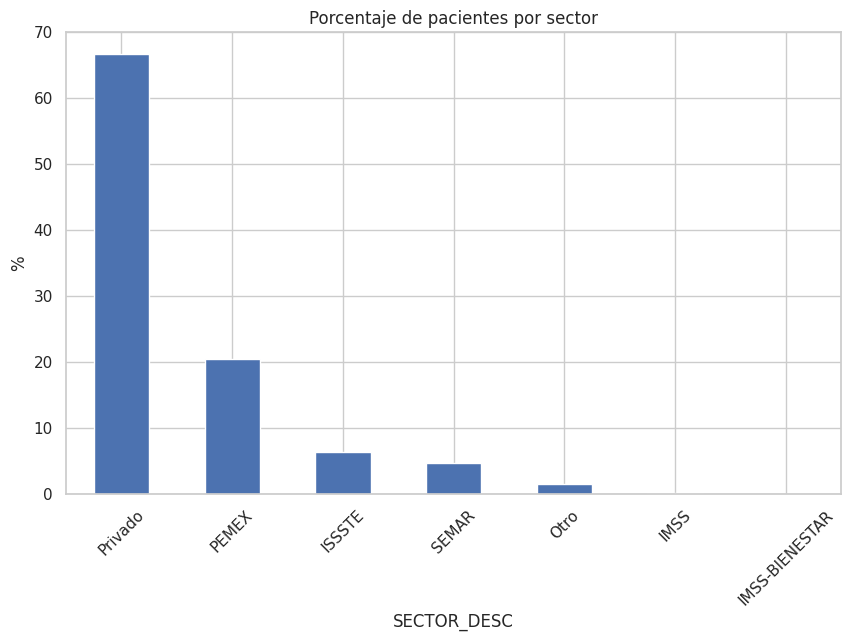

In [ ]:
sector_pct.plot(kind='bar')
plt.title("Porcentaje de pacientes por sector")
plt.ylabel("%")
plt.xticks(rotation=45)
plt.show()

Pregunta 5. Existe relacion entre edad y defuncion?

Tasa de defunción: 100.00%


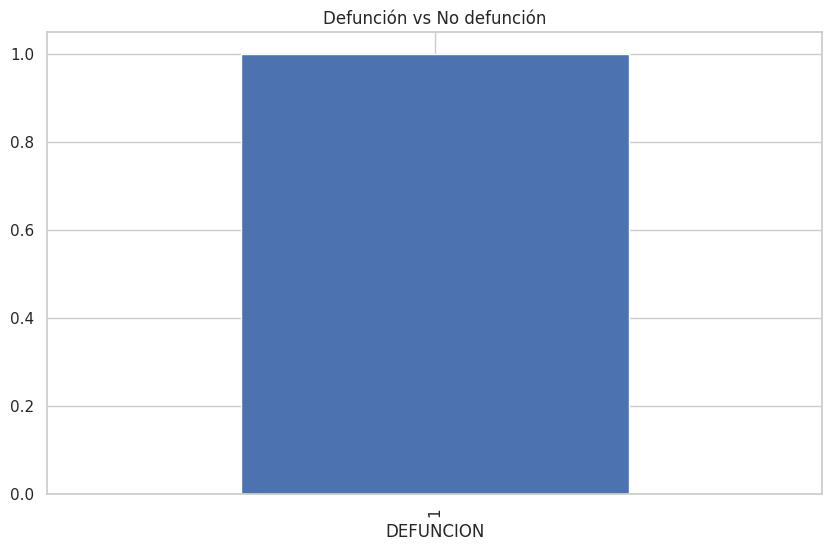

In [ ]:
# Crear variable binaria
df['DEFUNCION'] = df['FECHA_DEF'].notna().astype(int)

# Calcular tasa
tasa_def = df['DEFUNCION'].mean() * 100

print(f"Tasa de defunción: {tasa_def:.2f}%")

# Gráfica
df['DEFUNCION'].value_counts(normalize=True).plot(kind='bar')
plt.title("Defunción vs No defunción")
plt.show()

Cambio de pregunta 5. Cual es el porcentaje de personas segun su enfermedad cronica

In [ ]:
# Converion de data

enfermedades = ['DIABETES', 'HIPERTENSION', 'OBESIDAD', 'RENAL_CRONICA']

for col in enfermedades:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [ ]:
# Calculo de porcentaje

porcentajes = {}

for col in enfermedades:
    total = df[col].notna().sum()
    positivos = (df[col] == 1).sum()

    porcentaje = (positivos / total) * 100
    porcentajes[col] = porcentaje

In [ ]:
# Resultados

for enf, val in porcentajes.items():
    print(f"{enf}: {val:.2f}%")

DIABETES: 13.17%
HIPERTENSION: 15.89%
OBESIDAD: 6.70%
RENAL_CRONICA: 3.51%


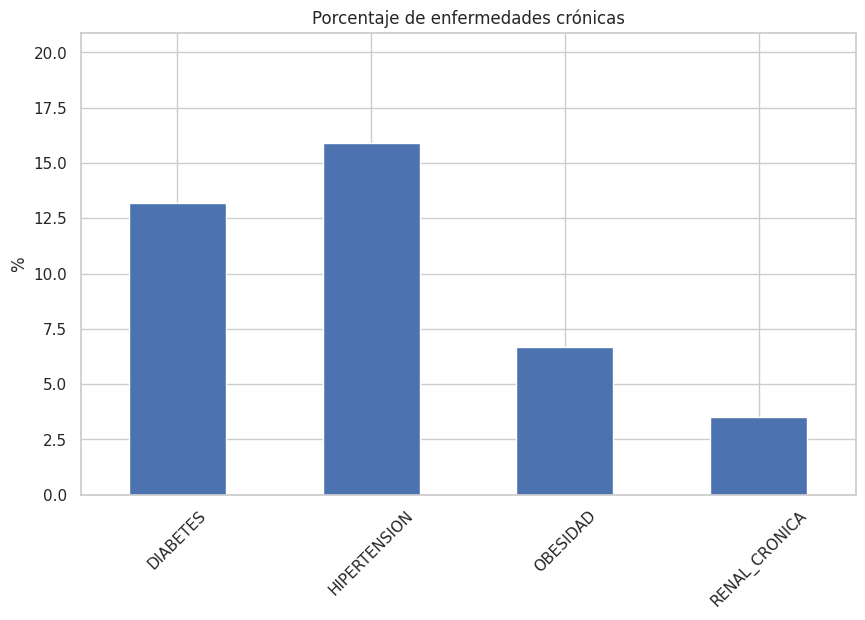

In [ ]:
# Graficos

import pandas as pd
import matplotlib.pyplot as plt

serie = pd.Series(porcentajes)

serie.plot(kind='bar')
plt.title("Porcentaje de enfermedades crónicas")
plt.ylabel("%")
plt.xticks(rotation=45)
plt.ylim(0, max(serie)+5)
plt.show()

# Parte 16. Conclusion

Conclusiones del dataset:

1. Se limpiaron valores inválidos (97, 98, 99) comunes en el dataset.
2. Se transformaron variables categóricas usando catálogos oficiales.
3. Se detectaron outliers en edad, aunque dentro de rangos razonables.
4. La mayoría de pacientes se concentra en ciertos rangos de edad.
5. Existen relaciones entre variables clínicas relevantes.



Conclusiones del analisis del proyeto Covid 19

1. Distribución de la población:
La mayoría de los pacientes no presenta enfermedades crónicas; sin embargo, existe una proporción significativa con diabetes, hipertensión y obesidad, lo que representa factores de riesgo importantes.

2. Edad como factor clave:
La edad se identificó como una de las variables más relevantes, observándose que los pacientes con enfermedades crónicas tienden a ser de mayor edad.

3. Relación entre enfermedades crónicas:
Se encontraron asociaciones entre enfermedades como diabetes, hipertensión y obesidad, lo que indica la presencia de comorbilidades.

4. Diferencias por sexo:
Se observaron diferencias en la distribución de edad y enfermedades entre hombres y mujeres, sugiriendo patrones demográficos relevantes.

5. Hospitalización y severidad:
Los pacientes hospitalizados presentan mayor edad y mayor presencia de enfermedades crónicas, lo que indica mayor severidad.

6. Calidad de los datos:
Se identificaron valores faltantes, inconsistencias en tipos de datos y codificaciones numéricas que requirieron limpieza y transformación.

7. Importancia del preprocesamiento:
La conversión de variables categóricas codificadas (1 = Sí, 2 = No) fue fundamental para obtener resultados correctos.

8. Utilidad del análisis exploratorio:
El EDA permitió identificar patrones, tendencias y relaciones entre variables, facilitando la comprensión de los datos.

CONCLUSIÓN GENERAL:
El análisis permitió identificar que la edad y las enfermedades crónicas son factores clave en la caracterización de los pacientes, destacando la importancia de una correcta preparación de los datos para obtener resultados confiables.
